In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [39]:
df=pd.read_csv('D:\Downloads\Teen_Mental_Health.csv')

In [40]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score,sleep_quality,digital_wellbeing_flag
0,14,male,7.9,Facebook,7.4,2.9,3.01,1.5,low,2,2,1,0,5,Fair,At Risk
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,19,Good,Moderate
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,8,Fair,Healthy
3,15,male,7.4,YouTube,6.9,1.6,3.48,0.8,medium,1,7,9,0,17,Fair,Moderate
4,15,female,4.7,All Platforms,4.9,3.0,2.37,1.4,medium,3,5,2,0,10,Poor,Moderate


In [41]:
df.shape

(1200, 16)

In [42]:
#understanding the data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
 13  mental_health_risk_score  1200 non-null   int64  
 14  sleep_qu

In [43]:
#analysing numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1200.0,15.928333,2.021947,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,1200.0,4.536667,2.029599,1.0,2.8,4.50,6.30,8.0
sleep_hours,1200.0,6.449417,1.442677,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1200.0,1.740333,0.716660,0.5,1.1,1.80,2.40,3.0
academic_performance,1200.0,2.990383,0.576758,2.0,2.5,2.99,3.48,4.0
physical_activity,1200.0,1.014500,0.582185,0.0,0.5,1.00,1.50,2.0
stress_level,1200.0,5.445833,2.903290,1.0,3.0,5.00,8.00,10.0
anxiety_level,1200.0,5.636667,2.859453,1.0,3.0,6.00,8.00,10.0
addiction_level,1200.0,5.565000,2.830627,1.0,3.0,6.00,8.00,10.0
depression_label,1200.0,0.025833,0.158704,0.0,0.0,0.00,0.00,1.0


In [44]:
#remapping the depression_label to Yes/No
df['depression_label'] = df['depression_label'].map({
    0: 'No',
    1: 'Yes'
})

In [45]:
#analysing non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns
for col in non_numeric_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: gender
['male' 'female']

Column: platform_usage
['Facebook' 'TikTok' 'Instagram' 'YouTube' 'All Platforms']

Column: social_interaction_level
['low' 'high' 'medium']

Column: depression_label
['No' 'Yes']

Column: sleep_quality
['Fair' 'Good' 'Poor']

Column: digital_wellbeing_flag
['At Risk' 'Moderate' 'Healthy']


In [46]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [47]:
#checking for null values
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
mental_health_risk_score    0
sleep_quality               0
digital_wellbeing_flag      0
dtype: int64

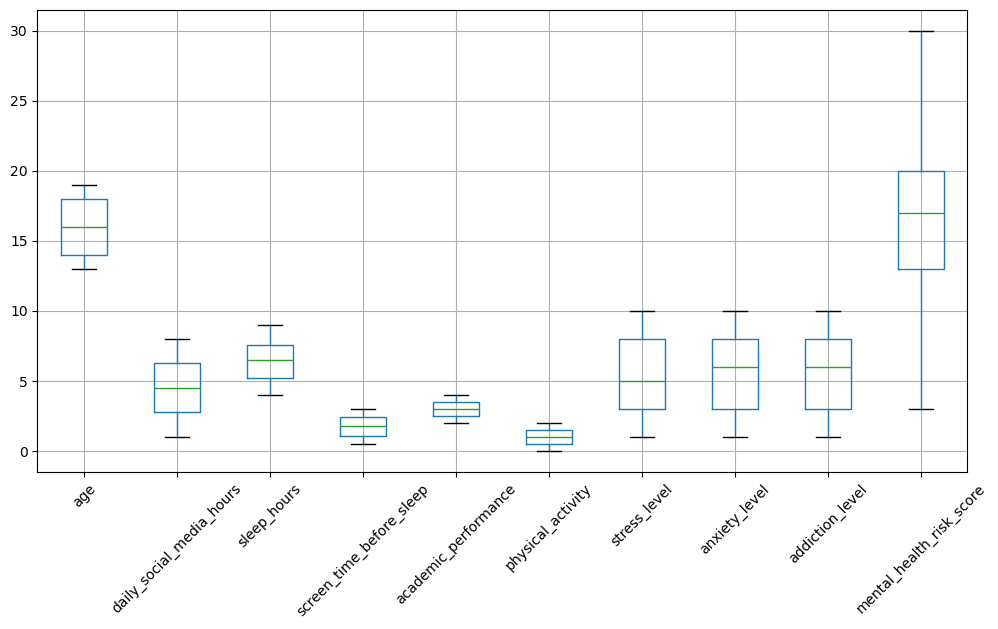

In [48]:
#checking for outliers
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [49]:
df.skew(numeric_only=True)

age                         0.017215
daily_social_media_hours    0.009172
sleep_hours                 0.016816
screen_time_before_sleep    0.010946
academic_performance        0.043702
physical_activity          -0.054842
stress_level                0.047630
anxiety_level              -0.036251
addiction_level            -0.042440
mental_health_risk_score   -0.087439
dtype: float64

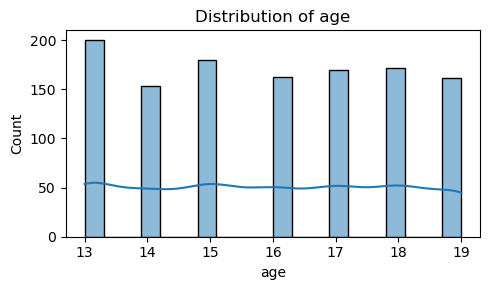

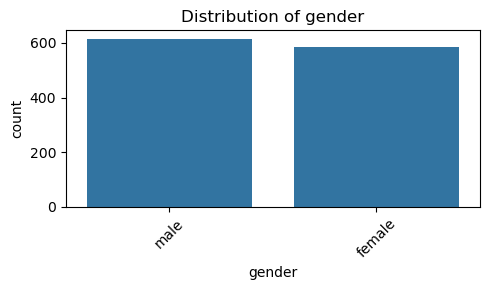

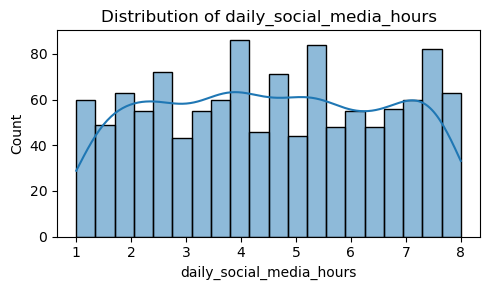

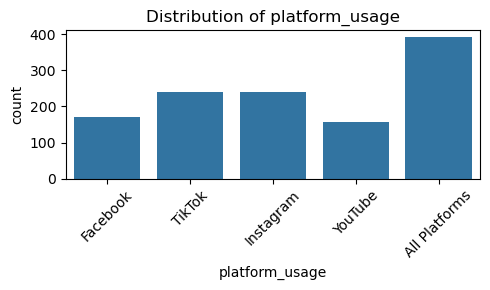

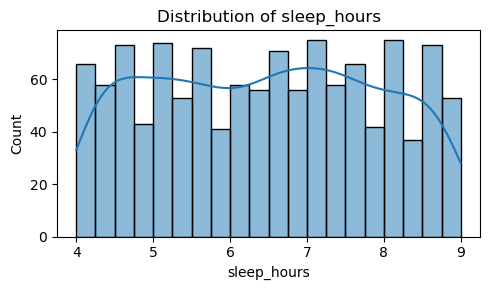

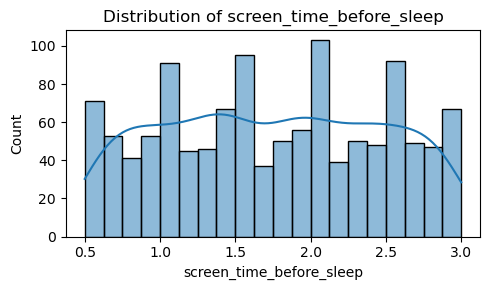

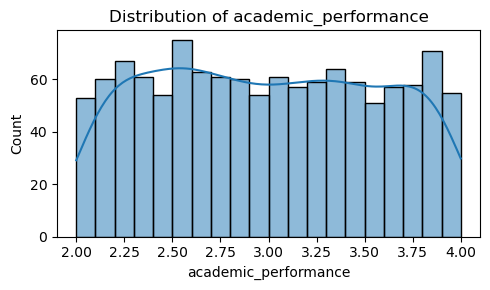

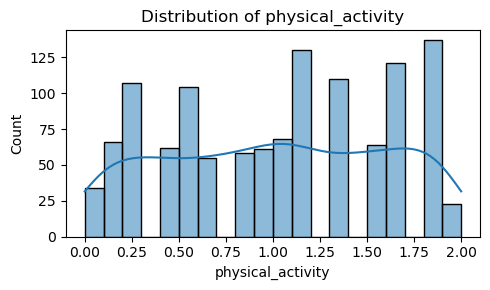

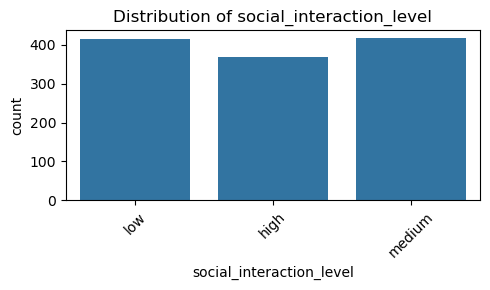

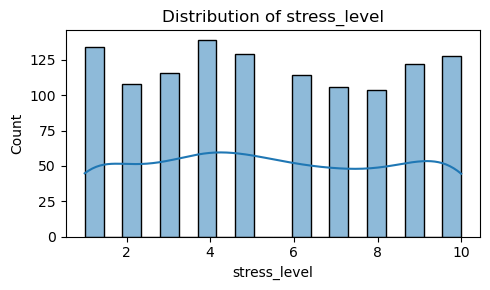

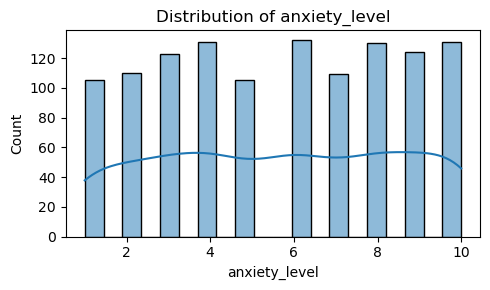

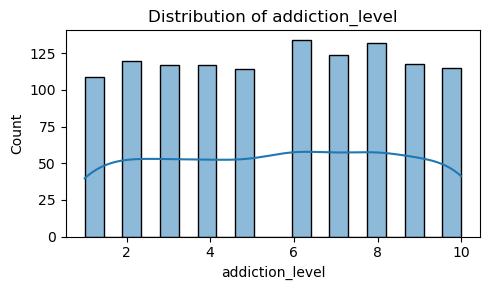

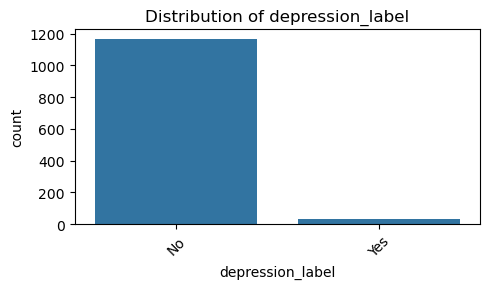

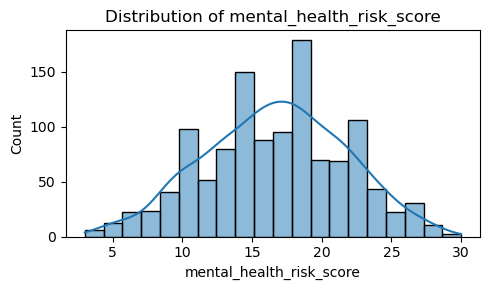

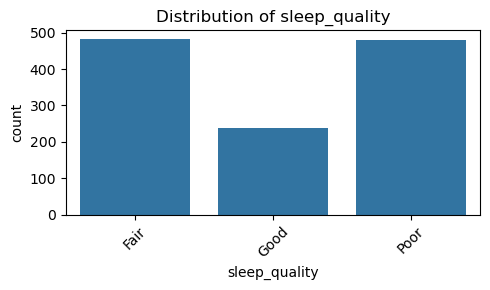

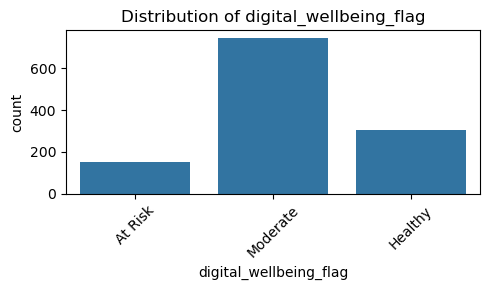

In [50]:
# visual representation for all columns
for col in df.columns:
    
    plt.figure(figsize=(5,3))
    
    # Numerical columns
    if df[col].dtype in ['int64', 'float64']:
        sns.histplot(df[col], kde=True, bins=20)
    
    # Categorical columns
    else:
        sns.countplot(x=df[col])
        plt.xticks(rotation=45)
    
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

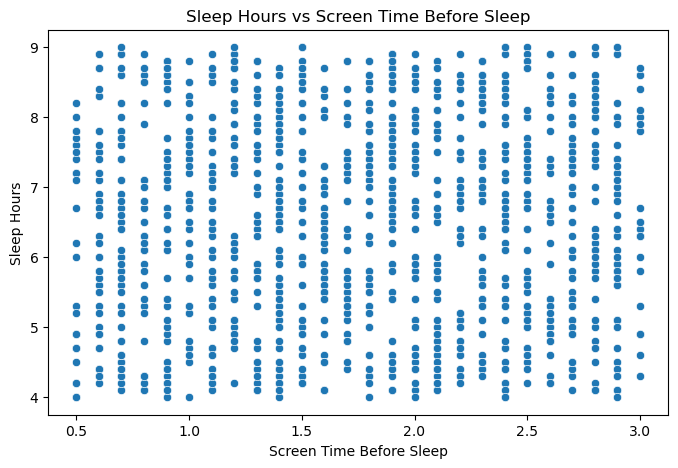

In [51]:
#checking for Sleep Hours vs Screen Time Before Sleep correlation
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='screen_time_before_sleep',
    y='sleep_hours',
    #hue='sleep_quality',
    palette='Set2'
)

plt.title('Sleep Hours vs Screen Time Before Sleep')
plt.xlabel('Screen Time Before Sleep')
plt.ylabel('Sleep Hours')

plt.show()

#no correlation

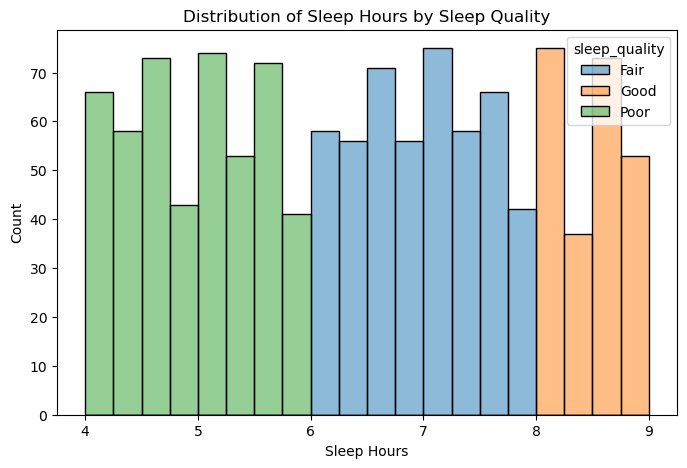

In [52]:
#checking for Sleep Hours by Sleep Quality correlation
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='sleep_hours',
    hue='sleep_quality',
    bins=20
)

plt.title('Distribution of Sleep Hours by Sleep Quality')
plt.xlabel('Sleep Hours')
plt.ylabel('Count')

plt.show()

#PATTERN: If Sleep Hours are low, Sleep Quality is bad

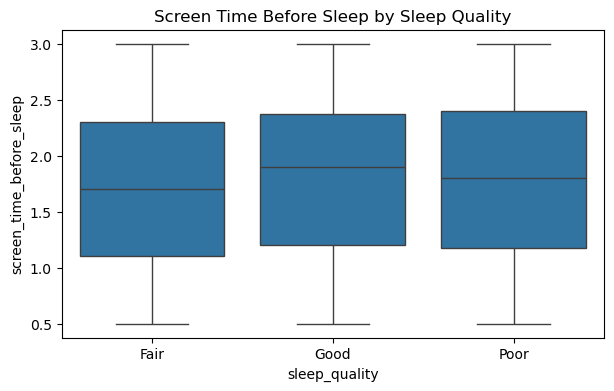

In [53]:
# Checking for Screen Time Before Sleep by Sleep Quality
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x='sleep_quality',
    y='screen_time_before_sleep'
)

plt.title('Screen Time Before Sleep by Sleep Quality')

plt.show()

#weak correlation

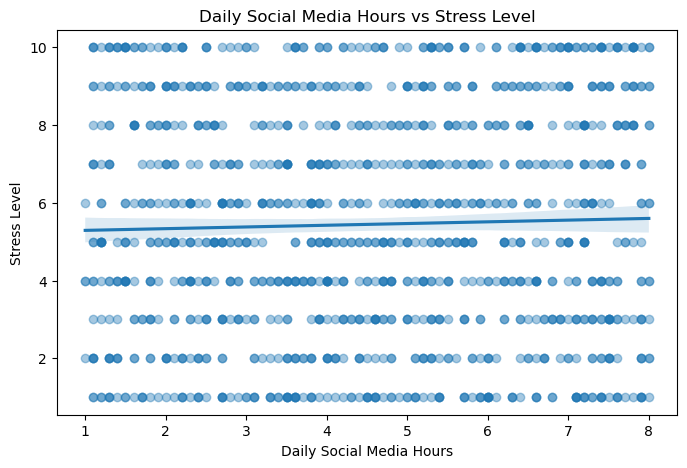

In [54]:
#checking for Daily Social Media Hours vs Stress Level correlation
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='daily_social_media_hours',
    y='stress_level',
    scatter_kws={'alpha':0.4}
)

plt.title('Daily Social Media Hours vs Stress Level')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Stress Level')

plt.show()
#weak correlation

In [55]:
df[['daily_social_media_hours', 'stress_level']].corr()

#weak correlation

,daily_social_media_hours,stress_level
daily_social_media_hours,1.000000,0.030698
stress_level,0.030698,1.000000


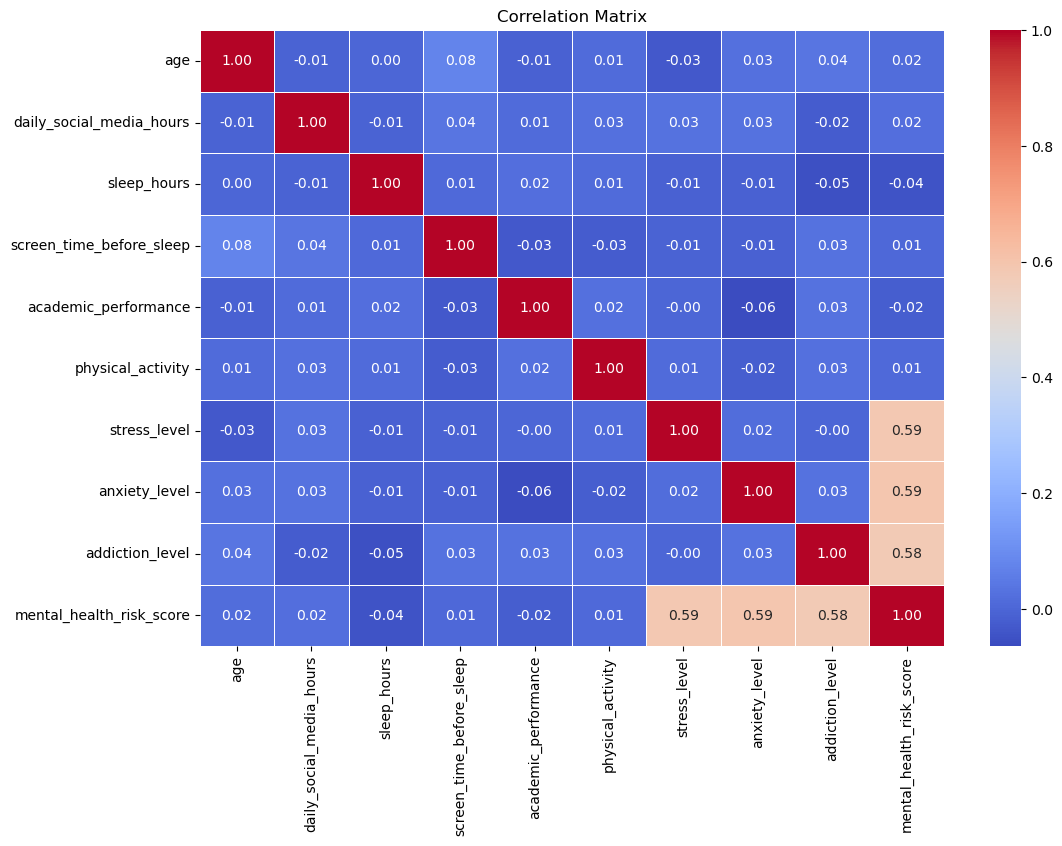

In [56]:
# Correlation matrix for numerical columns
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix')
plt.show()

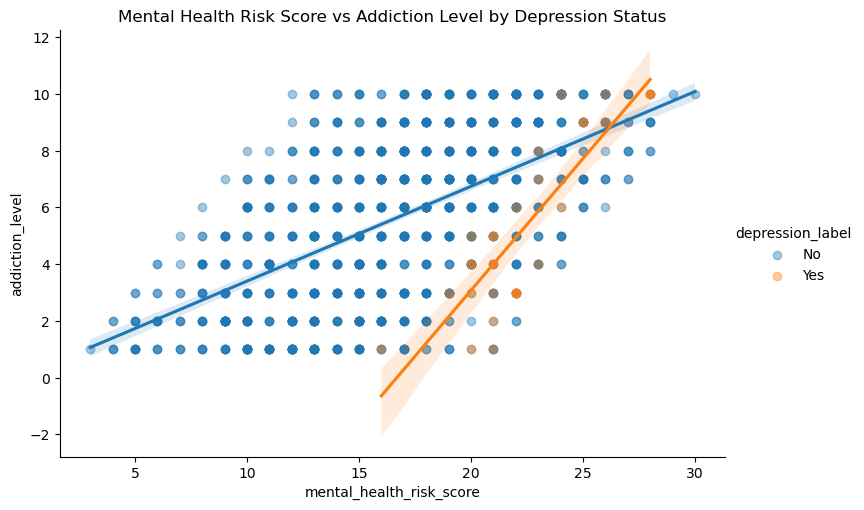

In [57]:
#checking for Mental Health Risk Score vs Addiction Level correlation
sns.lmplot(
    data=df,
    x='mental_health_risk_score',
    y='addiction_level',
    hue='depression_label',
    height=5,
    aspect=1.5,
    scatter_kws={'alpha':0.4}
)

plt.title('Mental Health Risk Score vs Addiction Level by Depression Status')
plt.show()

#suggesting a positive relation between addiction level and mental health risk score

In [58]:
#exploring depressed teens
print("Percent of teens depressed\n")
print(df['depression_label'].value_counts(normalize=True) * 100)

#most of the depressed teens have a mental_health_risk_score in the high range of 20--30

Percent of teens depressed

depression_label
No     97.416667
Yes     2.583333
Name: proportion, dtype: float64


In [59]:
df['depression_label'].value_counts()

#can't be confident in the patterns of depression label since the sample size has very few positives

depression_label
No     1169
Yes      31
Name: count, dtype: int64

In [60]:
df.groupby('depression_label')[
    ['sleep_hours',
     'daily_social_media_hours',
     'stress_level',
     'anxiety_level',
     'addiction_level',
     'mental_health_risk_score']
].mean()

#for exploratory purposes only, since we have only 31 records
#PATTERNS: higher values of every variable except addiction_level

,sleep_hours,daily_social_media_hours,stress_level,anxiety_level,addiction_level,mental_health_risk_score
depression_label,,,,,,
No,6.494183,4.478785,5.365269,5.557742,5.571429,16.494440
Yes,4.761290,6.719355,8.483871,8.612903,5.322581,22.419355


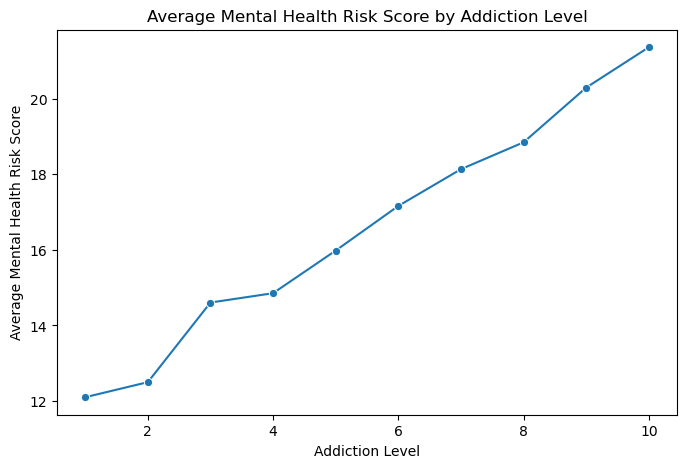

In [61]:
#representing the correlation between addiction level and mental health risk score
avg_risk = (
    df.groupby('addiction_level')['mental_health_risk_score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=avg_risk,
    x='addiction_level',
    y='mental_health_risk_score',
    marker='o'
)

plt.title('Average Mental Health Risk Score by Addiction Level')
plt.xlabel('Addiction Level')
plt.ylabel('Average Mental Health Risk Score')

plt.show()

#clearly a positive relationship: more the addiction, more the mental health risk

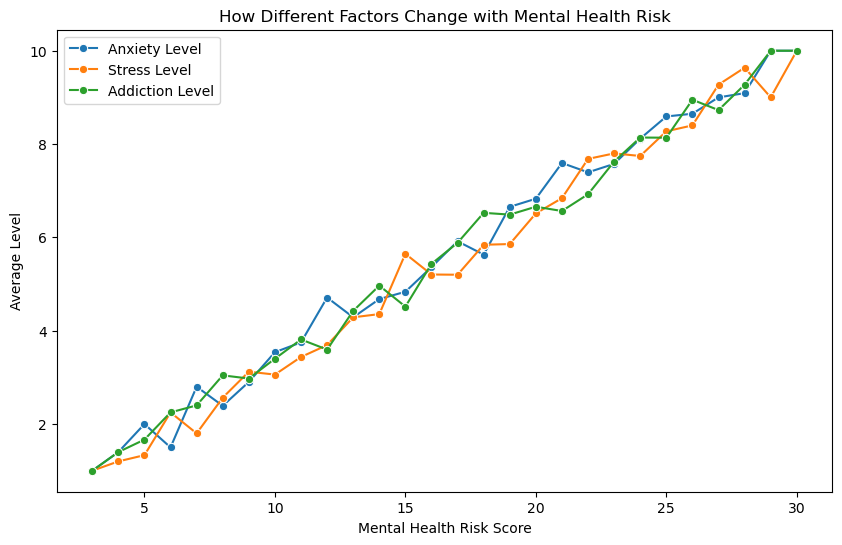

In [62]:
#checking mental_health_risk_score exists with anxiety, stress and addiction levels
avg_anxiety = (
    df.groupby('mental_health_risk_score')['anxiety_level']
      .mean()
      .reset_index()
)

avg_stress = (
    df.groupby('mental_health_risk_score')['stress_level']
      .mean()
      .reset_index()
)

avg_addiction = (
    df.groupby('mental_health_risk_score')['addiction_level']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=avg_anxiety,
    x='mental_health_risk_score',
    y='anxiety_level',
    marker='o',
    label='Anxiety Level'
)

sns.lineplot(
    data=avg_stress,
    x='mental_health_risk_score',
    y='stress_level',
    marker='o',
    label='Stress Level'
)

sns.lineplot(
    data=avg_addiction,
    x='mental_health_risk_score',
    y='addiction_level',
    marker='o',
    label='Addiction Level'
)

plt.title('How Different Factors Change with Mental Health Risk')
plt.xlabel('Mental Health Risk Score')
plt.ylabel('Average Level')
plt.legend()

plt.show()

#PROOF: mental_health_risk_score exists as a function of anxiety, stress and addiction levels

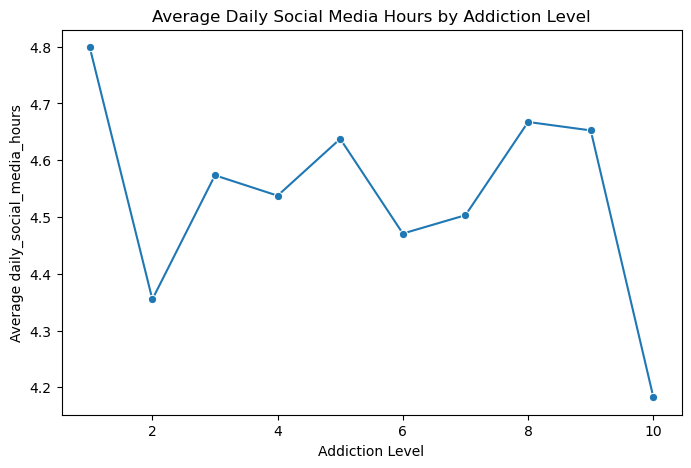

In [63]:
#checking the correlation between addiction level and daily_social_media_hours
avg_risk = (
    df.groupby('addiction_level')['daily_social_media_hours']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=avg_risk,
    x='addiction_level',
    y='daily_social_media_hours',
    marker='o'
)

plt.title('Average Daily Social Media Hours by Addiction Level')
plt.xlabel('Addiction Level')
plt.ylabel('Average daily_social_media_hours')

plt.show()

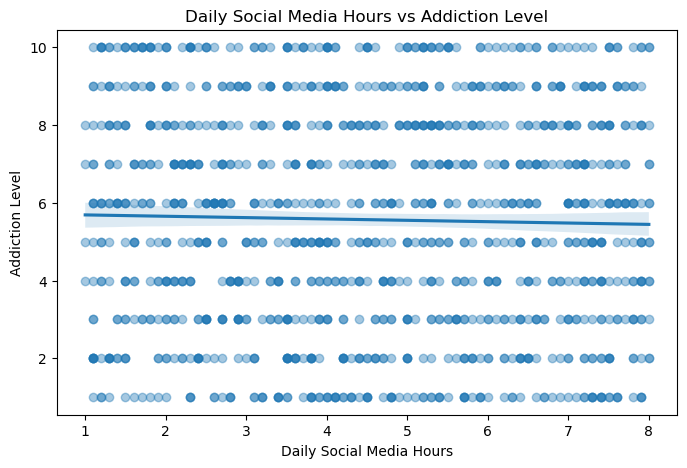

In [64]:
#checking the correlation between addiction level and daily_social_media_hours
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='daily_social_media_hours',
    y='addiction_level',
    scatter_kws={'alpha':0.4}
)

plt.title('Daily Social Media Hours vs Addiction Level')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Addiction Level')

plt.show()

#no relationship between daily_social_media_hours and addiction level
#contrary to common sense

In [65]:
df['risk_group'] = pd.cut(
    df['mental_health_risk_score'],
    bins=[0,10,20,30],
    labels=['Low','Moderate','High']
)

df.groupby('risk_group').mean(numeric_only=True)

#In this dataset, lifestyle and demographic factors showed minimal differences across mental health risk groups.

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,mental_health_risk_score
risk_group,,,,,,,,,,
Low,15.961039,4.249351,6.640909,1.720130,3.048896,0.989610,2.649351,2.785714,2.863636,8.298701
Moderate,15.923885,4.565748,6.441207,1.758530,2.986365,1.018898,5.152231,5.367454,5.375328,15.895013
High,15.922535,4.614437,6.367606,1.702465,2.969437,1.016197,7.750000,7.904930,7.538732,23.193662


In [66]:
#checking for patterns based on gender
print(df['gender'].value_counts(normalize=True) * 100)

gender
male      51.25
female    48.75
Name: proportion, dtype: float64


In [67]:
df.groupby('gender')[
    ['sleep_hours',
     'daily_social_media_hours',
     'stress_level',
     'anxiety_level',
     'addiction_level',
     'mental_health_risk_score']
].mean()

#stats for males and females are same

,sleep_hours,daily_social_media_hours,stress_level,anxiety_level,addiction_level,mental_health_risk_score
gender,,,,,,
female,6.496410,4.512991,5.422222,5.687179,5.48547,16.594872
male,6.404715,4.559187,5.468293,5.588618,5.64065,16.697561


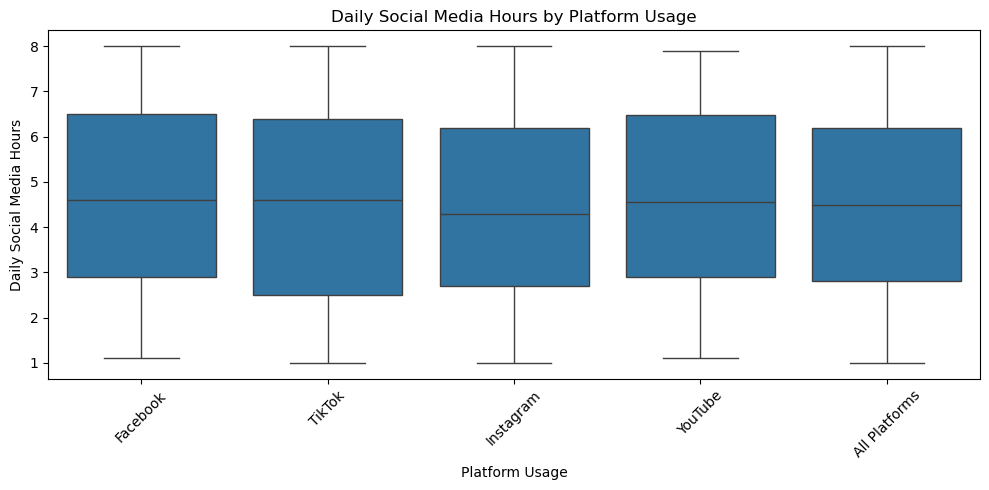

In [68]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='platform_usage',
    y='daily_social_media_hours'
)

plt.title('Daily Social Media Hours by Platform Usage')
plt.xlabel('Platform Usage')
plt.ylabel('Daily Social Media Hours')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#no strong correlation; teens are the same, whatever the platform they scroll on

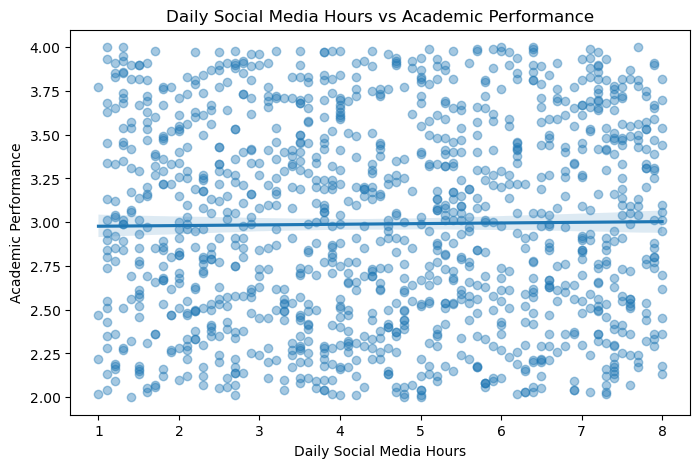

In [69]:
#Daily Social Media Hours vs Academic Performance
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='daily_social_media_hours',
    y='academic_performance',
    scatter_kws={'alpha': 0.4}
)

plt.title('Daily Social Media Hours vs Academic Performance')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Academic Performance')

plt.show()

In [70]:
corr = df['daily_social_media_hours'].corr(df['academic_performance'])
print(f'Correlation: {corr:.3f}')

#no correlation

Correlation: 0.013


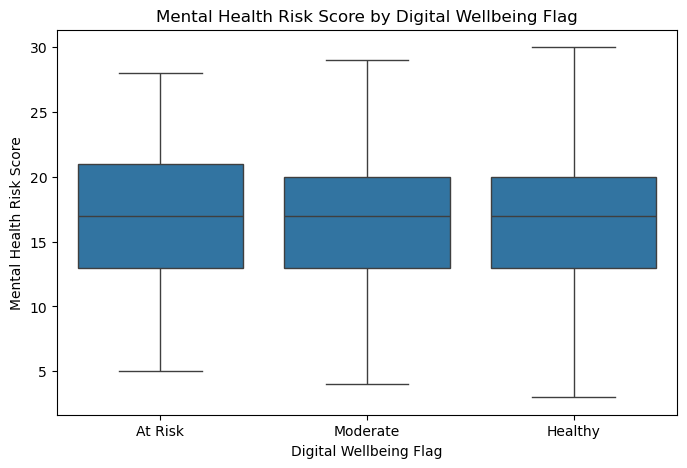

In [71]:
#checking for Mental Health Risk Score by Digital Wellbeing Flag correlation
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='digital_wellbeing_flag',
    y='mental_health_risk_score'
)

plt.title('Mental Health Risk Score by Digital Wellbeing Flag')
plt.xlabel('Digital Wellbeing Flag')
plt.ylabel('Mental Health Risk Score')

plt.show()

#no correlation

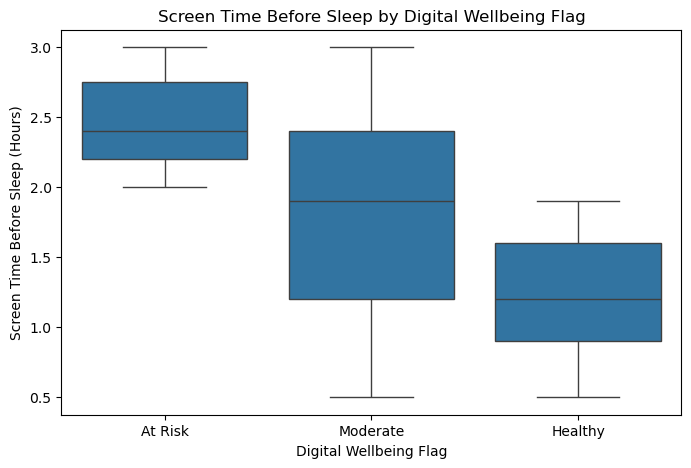

In [72]:
#checking for patterns between screen time habits and digital wellbeing
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='digital_wellbeing_flag',
    y='screen_time_before_sleep'
)

plt.title('Screen Time Before Sleep by Digital Wellbeing Flag')
plt.xlabel('Digital Wellbeing Flag')
plt.ylabel('Screen Time Before Sleep (Hours)')

plt.show()

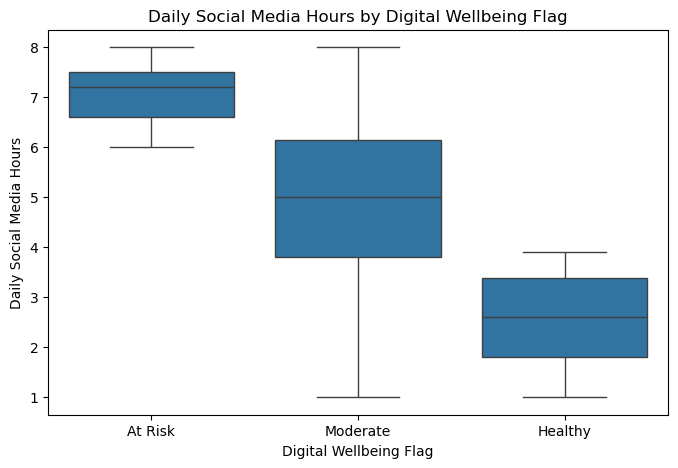

In [73]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='digital_wellbeing_flag',
    y='daily_social_media_hours'
)

plt.title('Daily Social Media Hours by Digital Wellbeing Flag')
plt.xlabel('Digital Wellbeing Flag')
plt.ylabel('Daily Social Media Hours')

plt.show()

In [74]:
#Teens who are at risk in terms of the digital well-being tend to scroll for longer hours